<img src="./images/logo-UVAIA-original.png" width= 200px>   

# Agentes con LangGraph     

LangGraph es una librería de LangChain que nos ofrece un framework para definir, coordinar y ejecutar multiples agentes de forma estructurada. A través de la creación y uso de **grafos cíclicos**.   

En LangGraph, el estado del grafo organiza el orden de tareas del agente, como el uso de herramientas y las llamadas a LLM, en un flujo de trabajo. El grafo utiliza un estado del agente para rastrear el progreso del agente en forma de texto, ayudando a determinar cuando se completa una tarea.    

A continuación, se construye un chatbot educativo que va a usar un LLM para responder preguntas.   

Para construir un agente sencillo, tan solo es necesario utilizar tres nodos y dos aristas, como se observa en el siguiente esquema:

<img src="./images/chatbotSchema.png" width=200 style="display: block; margin: auto;">

En LangGraph, como ya se ha mencionado, los nodos representan fuciones/tareas, como generar una respuesta o llamar a una herramienta ("tool"), mientras que las aristas ("edges") definen las conexiones que existen entre los nodos.   

Los nodos **INICIO (START)** y **FIN (END)** marcan el principio y el final del flujo de trabajo y se importan directamente desde LangGraph.

### Paso 0. Configuración previa

In [ ]:
# =====================================================================================
# 🔑  Introduce tus API keys en la linea correspondiente antes de ejecutar el notebook
# ==============================================================
import os


# Carga tu API key de Hugging Face en la siguiente variable. 
# Puedes obtenerla en https://huggingface.co/settings/tokens

HF_API_KEY = ""  # 👈 Pon aquí tu token de HuggingFace

# Configura la variable de entorno para Hugging Face
os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_API_KEY

print("✅ ¡API keys configuradas y listas para usar!")

✅ ¡API keys configuradas y listas para usar!


In [ ]:
# instalar librería langgraph - Sólo la primera vez que se ejecute el notebook
%pip install langgraph

### Paso 1. - Importamos librerías y módulos necesarios.

In [2]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace # conectamos con la API de Hugging Face

In [3]:
# Módulos para estructurar texto del chatbot
from typing import Annotated
from typing_extensions import TypedDict

# Módulos de LangGraph para definir el grafo de conversación
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

### Paso 2. - Configuramos el LLM que vamos a usar (Qwen3 en HF):

In [4]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-8B",                                            # Modelo gratuito en HF Inference API
    temperature=0.01,                                                   # Cercano a 0 para respuestas más determinísticas
    max_new_tokens=1024,                                                # Número máximo de tokens a generar.
    task="text-generation"                                              # Tipo de tarea que queremos realizar con el modelo. En este caso, generación de texto.
)

In [5]:
model = ChatHuggingFace(llm=llm)

### Paso 3.- Definimos el estado:    

En la clase `State()` se definen los mensajes con metadatos para estructurar la conversación entre el usuario y el agente. Estos mensajes se utilizarán para alimentar el grafo de conversación y permitir que el agente responda de manera coherente y contextualizada a las consultas del usuario.    
El tipo de dato `Annotated` se utiliza para agregar metadatos a la lista de mensajes, en este caso, el decorador `add_messages() `que indica que esta lista debe ser tratada como un historial de mensajes para el grafo de conversación.   

Lo siguiente es inicializar el **grafo de estados (StateGraph)**. Para ello creamos una instancia de `StateGraph` utilizando la clase `State` que hemos definido anteriormente para estructurar el estado del grafo con los mensajes de la conversación.      
El generador de grafos (`StateGraph`) nos permitirá definir las transiciones entre diferentes estados de la conversación, facilitando la gestión del diálogo entre el usuario y el agente.

In [6]:
class State(TypedDict):
    
    messages: Annotated[list, add_messages()] # lista que almacena toda la conversación.
    
# Inicializamos el grafo de estados (StateGraph) 
graph_builder = StateGraph(State) # 

### Paso 4.- Montaje de los nodos.   

Los **nodos** suelen ser funciones de Python que realizan una tarea específica, como por ejemplo

- Interactuar con un LLM
- Llamar a una herramienta o API
- Realizar alguna manipulación de datos
- Recibir la información del usuario
- Ejecutar la lógica empresarial

En nuestro caso, se define el **nodo de la función principal** denominado ***"chatbot"***, que acepta la clase `State`:    
- Se define una función `chatbot` que toma los mensajes de estado (state) como entrada y devuelve un nuevo estado con los mensajes actualizados.
- Dentro de la función, se usa el modelo de lenguaje (llm) para generar una respuesta basada en el historial de mensajes almacenado en el estado actual. 
- La función devuelve un diccionario con la clave "messages" que contiene la respuesta generada por el modelo, lo que permite al grafo de conversación actualizar el estado con la nueva información y continuar la interacción de manera coherente.   

LangGraph se encarga *automáticamente* de fusionar esa respuesta con el historial existente (no lo reemplaza, lo actualiza).

                   ` Estado actual (mensajes) → modelo LLM → nuevo mensaje → estado actualizado `  

Es, por tanto, el núcleo de nuestro agente conversacional: recibe el historial, genera una respuesta y la devuelve para que el grafo la incorpore al estado.

📌 Mencionar aquí que el *"estado"* es un objeto que se va actualizando por parte de los nodos a lo largo del tiempo, gestionando la situación interna del sistema. Puede añadirse o anularse, conteniendo elementos como:
- *Historia de la conversación*: Una lista de mensajes entre el agente y el usuario.
- *Datos contextuales*: Información relevante para la tarea o interacción actual.
- *Variables internas*: Indicadores, contadores u otras variables para seguir el progreso y el comportamiento del agente.


In [7]:
def chatbot(state: State):
    return {"messages":
        [model.invoke(state["messages"])]}

Se añade el nodo del chatbot al grafo. Para ello usamos la sintaxis `graph.add_node(nombre, valor)`, que en nuestro ejemplo queda como sigue:

In [8]:
graph_builder.add_node("chatbot", chatbot) # añadimos un nodo al grafo que representa la función chatbot.

Continuamos añadiendo *nodos* y *aristas*.    

- Definimos el principio y el final del grafo de conversación:   
    - Se define la transición desde el estado inicial (START) al nodo del chatbot, indicando que la conversación comienza con la función chatbot.
    - Se define la transición desde el nodo del chatbot al estado final (END), indicando que la conversación puede finalizar después de que el chatbot haya respondido.
    - Finalmente, se compila el grafo para que este listo y pueda ejecutarse. Esto conlleva la validación de las transiciones y preparar la estructura del grafo para manejar las conversaciones de manera eficiente.   

In [9]:
# Definimos la transición desde el estado inicial (START) al nodo del chatbot.
graph_builder.add_edge(START, "chatbot") 
# Definimos la transición desde el nodo del chatbot al estado final (END).
graph_builder.add_edge("chatbot", END) 
# Compilamos el grafo.
graph = graph_builder.compile() 

En ***LangGraph***, la transmisión de eventos desde un grafo permite procesar los pasos del flujo de trabajo de un agente en tiempo real. A medida que se transmite, cada evento representa un solo paso en el grafo, como generar una respuesta o llamar a una herramienta.   
Esto permite rastrear el progreso del agente del chatbot, mostrando respuestas tan pronto como estas estén listas.    

### Paso 5.- Generación de respuestas del ChatBot.

Para generar las respuestas de nuestro ChatBot empezamos definiendo una función que se encargará de ejecutar el chatbot basado en el input del usuario, lo que nos permitirá interactuar con el agente de manera sencilla y directa.   
Para ejecutar el grafo utilizamos la función `stream`, pasando un estado inicial que contiene el mensaje del usuario. La función `stream` devuelve un generador que produce eventos a medida que el grafo procesa la conversación.
Se va iterando sobre los valores de cada evento generado por el grafo, lo que permite acceder a las respuestas del chatbot a medida que se generan en tiempo real.    
Por último, se imprime la respuesta del agente a medida que se genera, lo que permite ver la interacción en tiempo real entre el usuario y el chatbot.

In [10]:
from IPython.display import display, Markdown                         # imports de librerías y modulos para salida con formato Markdown

def stream_graph_updates(user_input):
    for event in graph.stream({"messages": [("user", user_input)]}):  # ejecutamos el grafo utilizando la función stream.
        for value in event.values():                                  # iteramos sobre los valores de cada evento generado por el grafo.
            for msg in value["messages"]:
                display(Markdown(f"**🤖 Agente:**\n\n{msg.content}")) # imprimimos la respuesta del agente a medida que se genera. (Usamosformato Markdown)

Otra opción sería usar la función `invoke`, donde debe tenerse en cuenta que se realiza la ejecución de toda la conversación, devolviendo el estado final de la misma. Para tener un resultado equivalente al uso de la función `stream` es necesario implementar el código de la siguiente forma:

In [11]:
from IPython.display import display, Markdown   

def get_graph_response(user_message: str):
    result = graph.invoke({"messages": [{"role": "user", "content": user_message}]}) # Llama al grafo con el mensaje del usuario
    display(Markdown(f"**🤖 Agente:**\n\n {result['messages'][-1].content}"))            # Imprime la respuesta del asistente (último mensaje generado por el modelo)

### Paso 6.- Definición de la consulta a lanzar.    

Se define una consulta para el chatbot y seguidamente, se lanza la función para ver la respuesta del agente en tiempo real.

In [ ]:
query = "¿Quién es Ray Bradbury?" # definimos una consulta para el chatbot relacionada con el autor Ray Bradbury, lo que nos permitirá ver cómo el agente responde a preguntas de conocimiento general.

Ejecutamos la función `stream_graph_updates` pasando la consulta, lo que iniciará la interacción con el chatbot y mostrará la respuesta del agente basada solo en el *"conocimiento propio"* del LLM.

In [13]:
stream_graph_updates(query) 

**🤖 Agente:**



Ray Bradbury (1920–2012) fue un escritor estadounidense de ciencia ficción, ensayista y poeta reconocido por su influencia en la literatura y su visión crítica sobre la tecnología, la sociedad y la cultura. Nació en Waukegan, Illinois, y se destacó por su estilo poético y su capacidad para explorar temas universales como la censura, la libertad, la tecnología y la pérdida de la humanidad.

### Obras más conocidas:
- **"Fahrenheit 451" (1953)**: Su novela más famosa, ambientada en un futuro distópico donde los libros son prohibidos y los ciudadanos son controlados por la censura. El protagonista, Guy Montag, se convierte en un rebelde al descubrir el poder de la literatura.
- **"Las crónicas marcianas" (1950)**: Una colección de cuentos que imagina la colonización de Marte y aborda temas como la guerra, la exploración y la identidad humana.
- **"Algo malo esto manera" (1962)**: Una novela de fantasía que combina elementos de terror y misterio, con una narrativa que se desarrolla en un pueblo misterioso.

### Temas recurrentes:
- **Censura y libertad**: En "Fahrenheit 451", Bradbury critica la supresión del conocimiento y la libertad de pensamiento.
- **Tecnología y humanidad**: Explora los riesgos de la dependencia tecnológica y su impacto en la sociedad.
- **La importancia de la literatura**: Consideraba que los libros eran esenciales para preservar la cultura y la conciencia humana.

### Reconocimiento:
- Fue nominado al Premio Pulitzer en 1954 por "Fahrenheit 451", aunque no lo ganó.
- Su obra ha sido traducida a más de 30 idiomas y sigue siendo estudiada en escuelas y universidades.
- Falleció en 2012 a los 91 años, dejando un legado duradero en la ciencia ficción y la literatura contemporánea.

Bradbury es recordado no solo como un maestro de la ciencia ficción, sino también como un pensador profundo que utilizaba su escritura para reflexionar sobre el futuro de la humanidad.

Ahora ejecutamos la función `get_graph_response`para comprobar que obtenemos resultados similares, aunque usando la función `invoke` y mostrando un único resultado:

In [14]:
get_graph_response(query) # llamamos a la función get_graph_response para obtener la respuesta del grafo a la consulta definida.    

**🤖 Agente:**

 

Ray Douglas Bradbury (1920–2012) fue un escritor estadounidense de ciencia ficción, fantasía y literatura general, reconocido por su creatividad, estilo poético y exploración de temas profundos como la censura, la tecnología, la libertad y la condición humana. Es considerado uno de los maestros más influyentes de la ciencia ficción moderna.

### **Algunos aspectos clave de su vida y obra:**
1. **Nacimiento y formación:**  
   Nació el 22 de agosto de 1920 en Waukegan, Illinois. Aunque no estudió literatura formalmente, su pasión por la escritura se desarrolló desde joven, influenciado por autores como Edgar Allan Poe y H.G. Wells.

2. **Obras más destacadas:**  
   - **"Fahrenheit 451" (1953):** Su novela más famosa, un clásico de la ciencia ficción distópica que aborda la censura, la pérdida de la cultura y la opresión. El título se refiere a la temperatura en la que el papel arde, simbolizando la destrucción de conocimiento.  
   - **"Las crónicas marcianas" (1950):** Una antología de historias que exploran la colonización de Marte, mezclando elementos de ciencia ficción, misterio y crítica social.  
   - **"Algo malo esto manera" (1962):** Una novela de horror gótico que combina elementos de fantasía y miedo infantil.  
   - **"El jardín de los cerezos" (1961):** Una novela de ciencia ficción que aborda temas como la guerra, la tecnología y la esperanza.

3. **Estilo y temas:**  
   Bradbury combinaba un lenguaje poético con una visión crítica del mundo. Sus obras suelen incluir elementos de fantasía, tecnología y filosofía, a menudo con un tono melancólico o

El comportamiento es el mismo en un grafo simple, pero con `invoke()` el texto aparece todo de golpe al final, no de forma progresiva.      

La siguiente tabla refleja las situaciones en las que es aconsejable usar 'invoke' o 'stream':     


| invoke() | stream() |
|----------|----------|
|Resultado procesado programáticamente(guardar en BBDD, hacer cálculos,...)| Usuario esperando respuesta en tiempo real|
|Script / pipeline interno (sin mostrar progreso)| Grafo con múltiples nodos y es necesario mostrar progreso|
|No hay problemas de espera| Evitar sensación de 'cuelgue'|
|Proceso de testeo o depuración| Se construye o se usa una interfaz (al estilo de los chats tipo ChatGPT)|     

En resumen:   
- Si hay un **humano** mirando la pantalla → `stream()`
- Si es una **máquina** procesando el resultado → `invoke()`

### Paso 7. - Generando una imagen del grafo.   

Vamos a mostrar una representación visual del grafo de conversación utilizando la función `draw_mermaid_png`, lo que nos permitirá entender mejor la estructura y las transiciones del citado grafo.

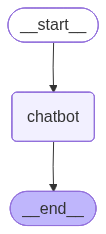

In [15]:
from IPython.display import Image, display 


try:
    display(Image(graph.get_graph().draw_mermaid_png())) # representación visual del grafo de conversación
    
except Exception as e:
    print("Se necesitan dependencias adicionales para mostrar el grafo visual.")

### Paso 8.- Añadiendo herramientas a nuestro ChatBot.     

Las herramientas dotadas de funcionalidades API (***API tools***) permiten aumentar las capacidades de los agentes chatbot al conceder acceso a recursos externos como sitios de noticias, bases de datos, redes sociales, ...      

Con **LangGraph** se va a proceder a ampliar el conocimiento del chatbot creado anteriormente, incluyendo una API de Wikipedia.    

Para ello, lo que hacemos seguidamente es instalar la biblioteca `wikipedia-api` para que nuestro agente acceda a la información de Wikipedia.

In [ ]:
%pip install wikipedia-api wikipedia

Instalamos también los módulos necesarios para crear la tool de Wikipedia:
- Por un lado, importamos la clase `WikipediaAPIWrapper` para crear una herramienta que permita al agente acceder a información de Wikipedia, lo que ampliará las capacidades del agente para responder preguntas basadas en conocimientos generales y específicos obtenidos de esta fuente y,
- por otra parte, importamos la clase `WikipediaQueryRun` para ejecutar consultas específicas a Wikipedia, lo que permitirá al agente obtener información detallada y precisa de esta fuente cuando sea necesario durante la conversación.    

In [16]:

from langchain_community.utilities import WikipediaAPIWrapper 
from langchain_community.tools import WikipediaQueryRun 

### Paso 9.- Inicializar la herramienta de Wikipedia.   

Se crea una instancia de WikipediaAPIWrapper para interactuar con la API de Wikipedia, configurando el parámetro top_k_results a 1 para limitar los resultados a la información más relevante obtenida de Wikipedia.      

Esto permitirá al agente acceder a datos actualizados y específicos durante las conversaciones, mejorando su capacidad para responder preguntas que requieran información adicional más allá de su conocimiento preentrenado.     

*Nota:* El parámetro `top_k_results` esta cargado con el valor 1 porque tan solo nos interesa el valor del primer resultado de la consulta, que damos por supuesto que es el que realmente buscamos.
                                                   

In [17]:
wikipedia = WikipediaAPIWrapper(top_k_results=1) 

### Paso 10.- Generación de la tool de Wikipedia.    

Aquí *se crea* la herramienta de Wikipedia utilizando `WikipediaQueryRun`,lo que permitirá al agente ejecutar consultas específicas a Wikipedia y obtener información relevante durante las conversaciones.   

Una vez creada la herramienta, se añade a la lista de herramientas del agente.

In [18]:
wikipedia_tool = WikipediaQueryRun(api_wrapper=wikipedia) 
tools = [wikipedia_tool] # añadimos la herramienta de Wikipedia a la lista de herramientas disponibles para el agente.

### Paso 11.- Integración de la nueva tool al grafo.    

Se vincula la herramienta de Wikipedia al grafo para que el agente pueda utilizarla durante la conversación.

In [19]:
model_with_tools = model.bind_tools(tools) # vinculamos el modelo de lenguaje (llm) con la lista de herramientas.

### Paso 12.- Modificación del chatbot para que utilice las nuevas herramientas.    

Se modifica la función chatbot para que utilice el modelo de lenguaje vinculado con las herramientas, lo que permitirá al agente acceder a la información de Wikipedia cuando sea necesario durante la conversación, mejorando así su capacidad para responder preguntas que requieran conocimientos adicionales.

In [20]:
def chatbot(state: State):
    return {"messages":
        [model_with_tools.invoke(state["messages"])]}

Añadimos nuevos módulos y librerias, que nos proporcionan la posibilidad de añadir estructuras condicionales a las herramientas y nodos del grafo

In [21]:
from langgraph.prebuilt import ToolNode, tools_condition 

### Paso 13.- Reiniciar el grafo de estados.


In [22]:
graph_builder = StateGraph(State) 
# Añadimos el nodo del chatbot al grafo
graph_builder.add_node("chatbot", chatbot) 

Creamos un **ToolNode** para la herramienta de Wikipedia.   

- Se crea un nodo de herramienta (ToolNode) que contiene la herramienta de Wikipedia.
- Se añade el nodo de herramientas al grafo, lo que permitirá al agente acceder a la herramienta de Wikipedia durante la conversación.

In [23]:
tool_node = ToolNode(tools=[wikipedia_tool]) 
graph_builder.add_node("tools", tool_node) 

### Paso 14.- Establecemos la nueva 'variación' en el flujo del grafo.    

Proporcionamos una condicion para dirigir desde el chabot al nodo de herramientas cuando el agente necesite acceder a Wikipedia para responder una consulta.    
Para ello, se añade una transición condicional desde el nodo del chatbot al nodo de herramientas, utilizando la función `tools_condition` para determinar cuándo el agente debe acceder a la herramienta de Wikipedia durante la conversación. 

In [24]:
graph_builder.add_conditional_edges("chatbot",tools_condition)

Se conectan las tools **"hacia atrás"** al chatbot para que el agente pueda volver a responder después de usar la herramienta de Wikipedia.   

Después se añaden los nodos de *inicio* y *fin* del grafo para completar la estructura de la conversación.

In [25]:
graph_builder.add_edge("tools", "chatbot") # añadimos una transición desde el nodo de herramientas de vuelta al nodo del chatbot.
graph_builder.add_edge(START, "chatbot") # definimos la transición desde el estado inicial (START) al nodo del chatbot.
graph_builder.add_edge("chatbot", END) # definimos la transición desde el nodo del chatbot al estado final (END).

### Paso 15.- Compilación del grafo.

In [26]:
graph = graph_builder.compile()

### Paso 16.- Visualización del grafo modificado.   

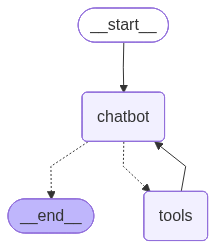

In [27]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Paso 17.- Probamos la modificación con una consulta *ad hoc*

In [29]:
query = "¿Quién es Ray Bradbury según Wikipedia?"

for event in graph.stream({"messages": [("user", query)]}):
    for value in event.values():
        for msg in value["messages"]:
            if msg.content:
                display(Markdown(f"**🤖 Agente:**\n\n{msg.content}"))

**🤖 Agente:**

Page: Ray Bradbury
Summary: Ray Douglas Bradbury (US:  BRAD-berr-ee; 22 August 1920 – 5 June 2012) was an American author and screenwriter. One of the most celebrated 20th-century American writers, he worked in a variety of genres, including fantasy, science fiction, horror, mystery, and realistic fiction.
Bradbury is best known for his novel Fahrenheit 451 (1953) and his short-story collections The Martian Chronicles (1950), The Illustrated Man (1951), and The October Country (1955). Other notable works include the coming of age novel Dandelion Wine (1957), the dark fantasy Something Wicked This Way Comes (1962) and the fictionalized memoir Green Shadows, White Whale (1992). He also wrote and consulted on screenplays and television scripts, including Moby Dick and It Came from Outer Space. Many of his works were adapted into television and film productions as well as comic books. Bradbury also wrote poetry which has been published in several collections, such as They Have Not Seen the Stars (2001).
The New York Times called Bradbury "An author whose fanciful imagination, poetic prose, and mature understanding of human character have won him an international reputation" and "the writer most responsible for bringing modern science fiction into the literary mainstream".



**🤖 Agente:**



Ray Douglas Bradbury (22 de agosto de 1920 – 5 de junio de 2012) fue un autor y guionista estadounidense, considerado uno de los escritores más celebrados del siglo XX. Trabajó en diversos géneros, como fantasía, ciencia ficción, terror, misterio y ficción realista. Es conocido especialmente por su novela *Fahrenheit 451* (1953) y sus recopilaciones de cuentos cortos como *Las Crónicas de Marte* (1950), *El Hombre Ilustrado* (1951) y *El Mes de Octubre* (1955). Otras obras destacadas incluyen *Vinagreta* (1957), *Algo Malo Esta Pasando Esta Manera* (1962) y el libro ficticio *Verdes Sombras, Blanca Ballena* (1992). También escribió guiones para películas y series, como *Moby Dick* y *Vino de Otros Planetas*. Muchas de sus obras se adaptaron a cine, televisión y cómics. Bradbury también publicó poemas en recopilaciones como *No Han Visto las Estrellas* (2001). El *New York Times* lo describió como "un autor cuya imaginación fantástica, prosa poética y comprensión madura del carácter humano han ganado una reputación internacional" y "el escritor más responsable de llevar la ciencia ficción moderna al ámbito literario".

<!-- Nota -->
<div style="background-color: #fff3cd; color: #000000 ;padding: 15px; border-radius: 5px;">    

#### 📌 Nota.    
En esta última respuesta, el agente está mostrando todos los mensajes del historial, no solo el final:    

    1-El modelo genera una primera respuesta en inglés (su idioma natural por defecto).   
    2-La herramienta de Wikipedia devuelve texto
    3-El modelo genera una segunda respuesta en castellano (porque la pregunta estaba en castellano)

Nuestro código, usando un bucle, nos muestra ambas respuestas al iterar sobre todos los mensajes con contenido.

📢❗🚨 En ocasiones, por problemas de Timeout, se generan errores de comunicación. Podemos reintentar lanzar la consulta o cambiar el idioma de la consulta ('Who is Ray Bradbury according to Wikipedia')

</div>